<a href="https://colab.research.google.com/github/shwetakul2005/mental-health-project/blob/main/WESAD_Dysregulation_Severity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd

In [ ]:

full_df_drive = pd.read_pickle("/content/drive/MyDrive/wesad_full_preprocessed.pkl")

In [ ]:
full_df = full_df_drive

In [ ]:
full_df.head()

,bpm,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,label,scr_peak_freq,scr_amp_mean,scl_mean,scl_slope,lf_power,HRV_MeanNN_bvp,HRV_SDNN_bvp,HRV_RMSSD_bvp,temp_mean,temp_std,subject
0,71.600077,837.987928,64.162813,50.240556,1,61.0,0.003176,2.190200,-0.000006,8.728580e-07,863.511029,307.907430,444.194808,35.828750,0.054123,S2
1,71.620713,837.746479,48.339731,45.156809,1,94.5,0.002594,1.975037,-0.000005,2.750015e-07,837.765957,172.185794,246.604310,35.790833,0.032573,S2
2,72.004891,833.276723,54.334890,51.117295,1,97.5,0.002551,1.802472,-0.000004,5.179775e-07,829.545455,143.060255,199.981603,35.850833,0.057163,S2
3,72.173560,831.329365,55.154117,50.347728,1,60.0,0.003149,1.673080,-0.000003,4.824999e-07,837.698063,152.479423,209.321405,35.907167,0.017377,S2
4,72.042895,832.837163,53.472406,50.318617,1,47.5,0.003630,1.571895,-0.000002,2.903708e-07,800.253378,176.838133,223.154754,35.903917,0.020178,S2


In [ ]:
# Autonomic dysregulation severity mapping
SEVERITY_MAP = {
    1: 0.0,   # baseline     — no dysregulation
    2: 0.8,   # stress       — high dysregulation
    3: 0.2,   # amusement    — mild activation, low clinical relevance
    4: 0.0,   # meditation   — treated same as baseline (relaxed state)
    0: None,  # undefined    — drop
}

# Apply to full_df BEFORE normalization
full_df_reg = full_df.copy()
full_df_reg['severity'] = full_df_reg['label'].map(SEVERITY_MAP)
full_df_reg = full_df_reg[full_df_reg['severity'].notna()].reset_index(drop=True)

print(full_df_reg['severity'].value_counts())
print(f"\nSeverity stats:\n{full_df_reg['severity'].describe()}")

severity
0.0    424
0.8    167
0.2     94
Name: count, dtype: int64

Severity stats:
count    685.000000
mean       0.222482
std        0.334939
min        0.000000
25%        0.000000
50%        0.000000
75%        0.200000
max        0.800000
Name: severity, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
def add_derived_features(df):
    df = df.copy()
    df['eda_hrv_ratio']   = df['scl_mean'] / (df['HRV_RMSSD'] + 1e-8)
    df['bpm_hrv_ratio']   = df['bpm'] / (df['HRV_SDNN'] + 1e-8)
    df['hrv_chest_wrist'] = df['HRV_RMSSD'] - df['HRV_RMSSD_bvp']
    df['scl_scr_ratio']   = df['scl_mean'] / (df['scr_peak_freq'] + 1e-8)
    return df

FEATURE_COLS = [
    'bpm', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD',
    'scr_peak_freq', 'scr_amp_mean', 'scl_mean',
    'scl_slope', 'lf_power',
    'HRV_MeanNN_bvp', 'HRV_SDNN_bvp', 'HRV_RMSSD_bvp',
    'temp_mean', 'temp_std',
    'eda_hrv_ratio', 'bpm_hrv_ratio', 'hrv_chest_wrist', 'scl_scr_ratio'
]
INPUT_SIZE = len(FEATURE_COLS)

full_df_reg = add_derived_features(full_df_reg)

def normalize_per_subject(df, feature_cols):
    df = df.copy()
    for subj in df['subject'].unique():
        mask = df['subject'] == subj
        scaler = StandardScaler()
        df.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])
    return df

full_df_norm = normalize_per_subject(full_df_reg, FEATURE_COLS)

# Splits
TRAIN_SUBJECTS = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11']
VAL_SUBJECTS   = ['S13','S14']
TEST_SUBJECTS  = ['S15','S16','S17']

train_df = full_df_norm[full_df_norm['subject'].isin(TRAIN_SUBJECTS)].reset_index(drop=True)
val_df   = full_df_norm[full_df_norm['subject'].isin(VAL_SUBJECTS)].reset_index(drop=True)
test_df  = full_df_norm[full_df_norm['subject'].isin(TEST_SUBJECTS)].reset_index(drop=True)

In [ ]:
X   = train_df[FEATURE_COLS].head()

In [ ]:
X

,bpm,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,scr_peak_freq,scr_amp_mean,scl_mean,scl_slope,lf_power,HRV_MeanNN_bvp,HRV_SDNN_bvp,HRV_RMSSD_bvp,temp_mean,temp_std,eda_hrv_ratio,bpm_hrv_ratio,hrv_chest_wrist,scl_scr_ratio
0,0.059012,-0.125604,-0.270823,-0.319535,0.234729,-0.441830,1.567353,-1.842264,-0.365267,-0.161544,0.259097,0.353171,1.361839,-0.256934,1.059884,0.100493,-0.362254,-0.388830
1,0.063433,-0.130107,-1.335127,-0.726577,1.289729,-0.458819,1.210047,-1.556315,-0.365857,-0.591593,-0.419607,-0.359270,1.323643,-0.830673,1.068426,1.690788,0.321835,-0.499574
2,0.145747,-0.213473,-0.931876,-0.249337,1.384207,-0.460063,0.923484,-1.182292,-0.365617,-0.728910,-0.565256,-0.527375,1.384084,-0.175985,0.562191,1.010633,0.508694,-0.517382
3,0.181886,-0.249794,-0.876773,-0.310954,0.203237,-0.442622,0.708613,-0.880264,-0.365652,-0.592727,-0.518153,-0.493699,1.440832,-1.235222,0.440885,0.938334,0.472770,-0.448023
4,0.153890,-0.221672,-0.989890,-0.313285,-0.190420,-0.428583,0.540582,-0.740202,-0.365841,-1.218209,-0.396342,-0.443821,1.437558,-1.160654,0.321928,1.106675,0.423508,-0.409587


In [ ]:
X.shape

(5, 18)

In [ ]:
SEQ_LEN = 5

def create_sequences_regression(df, feature_cols, seq_len):
    X_all, y_all = [], []
    for subj in df['subject'].unique():
        sdf = df[df['subject'] == subj].reset_index(drop=True)
        X   = sdf[feature_cols].values.astype(np.float32)
        y   = sdf['severity'].values.astype(np.float32)  # float now
        if len(X) < seq_len:
            continue
        for i in range(len(X) - seq_len + 1):
            X_all.append(X[i:i+seq_len])
            y_all.append(np.mean(y[i:i+seq_len]))  # mean severity over window
    return np.array(X_all), np.array(y_all)

X_train_seq, y_train_seq = create_sequences_regression(train_df, FEATURE_COLS, SEQ_LEN)
X_val_seq,   y_val_seq   = create_sequences_regression(val_df,   FEATURE_COLS, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences_regression(test_df,  FEATURE_COLS, SEQ_LEN)

print(f"X_train: {X_train_seq.shape} | y_train: {y_train_seq.shape}")
print(f"y_train unique values: {np.unique(y_train_seq)}")

X_train: (413, 5, 18) | y_train: (413,)
y_train unique values: [0.         0.04       0.08       0.12       0.16       0.2
 0.32       0.48000002 0.64       0.8       ]


In [ ]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_loader_reg(X, y, batch_size=32, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)  # float32, not long
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader_reg(X_train_seq, y_train_seq, shuffle=True)
val_loader   = make_loader_reg(X_val_seq,   y_val_seq,   shuffle=False)
test_loader  = make_loader_reg(X_test_seq,  y_test_seq,  shuffle=False)

In [ ]:
X_train_seq.shape

(413, 5, 18)

In [ ]:
class BiLSTMRegression(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        # self.attention = Attention(hidden_size)  # same Attention class as before
        self.bn        = nn.BatchNorm1d(hidden_size * 2)
        self.fc        = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),      # single output neuron
            nn.Sigmoid()           # clamps output to 0-1 range
        )

    def forward(self, x):
        out, _  = self.lstm(x)
        # context = self.attention(out)
        out = out[:, -1, :]
        context = self.bn(out)
        return self.fc(context).squeeze(1)  # shape: (batch,)

HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.3
LR          = 0.001
NUM_EPOCHS  = 80
PATIENCE    = 15

model     = BiLSTMRegression(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
criterion = nn.MSELoss()          # regression loss
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [ ]:
train_losses, val_losses = [], []
best_val_loss    = float('inf')
best_model_state = None
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_loss += criterion(model(X_batch), y_batch).item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step()

    print(f"Epoch {epoch+1:02d} | Train MSE: {avg_train:.4f} | Val MSE: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f"  ✓ New best val loss: {best_val_loss:.3f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 01 | Train MSE: 0.0847 | Val MSE: 0.1236
  ✓ New best val loss: 0.124
Epoch 02 | Train MSE: 0.0221 | Val MSE: 0.0572
  ✓ New best val loss: 0.057
Epoch 03 | Train MSE: 0.0131 | Val MSE: 0.0196
  ✓ New best val loss: 0.020
Epoch 04 | Train MSE: 0.0105 | Val MSE: 0.0143
  ✓ New best val loss: 0.014
Epoch 05 | Train MSE: 0.0086 | Val MSE: 0.0185
Epoch 06 | Train MSE: 0.0094 | Val MSE: 0.0097
  ✓ New best val loss: 0.010
Epoch 07 | Train MSE: 0.0082 | Val MSE: 0.0139
Epoch 08 | Train MSE: 0.0077 | Val MSE: 0.0219
Epoch 09 | Train MSE: 0.0091 | Val MSE: 0.0105
Epoch 10 | Train MSE: 0.0076 | Val MSE: 0.0109
Epoch 11 | Train MSE: 0.0070 | Val MSE: 0.0154
Epoch 12 | Train MSE: 0.0065 | Val MSE: 0.0136
Epoch 13 | Train MSE: 0.0070 | Val MSE: 0.0294
Epoch 14 | Train MSE: 0.0064 | Val MSE: 0.0172
Epoch 15 | Train MSE: 0.0067 | Val MSE: 0.0191
Epoch 16 | Train MSE: 0.0059 | Val MSE: 0.0194
Epoch 17 | Train MSE: 0.0059 | Val MSE: 0.0256
Epoch 18 | Train MSE: 0.0056 | Val MSE: 0.0256
Epoch 19 

MSE:  0.0141
RMSE: 0.1188
MAE:  0.0834


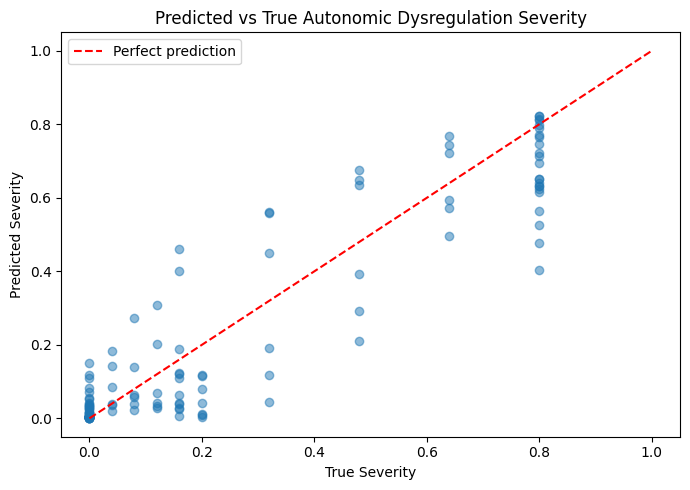

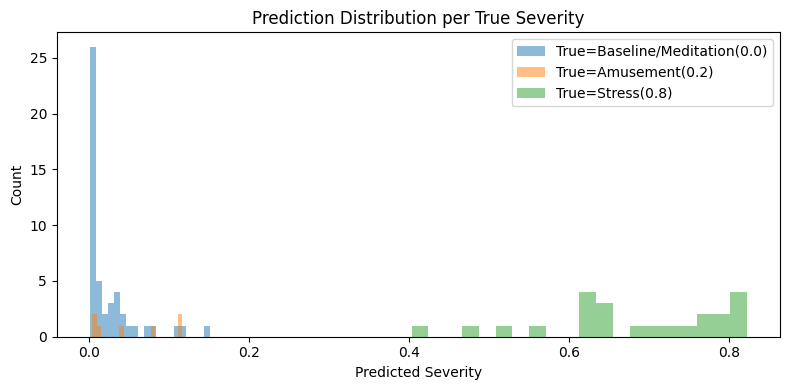

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

mse  = mean_squared_error(all_targets, all_preds)
mae  = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mse)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

# Scatter plot: predicted vs actual severity
plt.figure(figsize=(7, 5))
plt.scatter(all_targets, all_preds, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('True Severity')
plt.ylabel('Predicted Severity')
plt.title('Predicted vs True Autonomic Dysregulation Severity')
plt.legend()
plt.tight_layout()
plt.show()

# Distribution of predictions per true severity level
plt.figure(figsize=(8, 4))
for val, name in [(0.0, 'Baseline/Meditation'), (0.2, 'Amusement'), (0.8, 'Stress')]:
    mask = all_targets == val
    if mask.sum() > 0:
        plt.hist(all_preds[mask], bins=20, alpha=0.5, label=f'True={name}({val})')
plt.xlabel('Predicted Severity')
plt.ylabel('Count')
plt.title('Prediction Distribution per True Severity')
plt.legend()
plt.tight_layout()
plt.show()

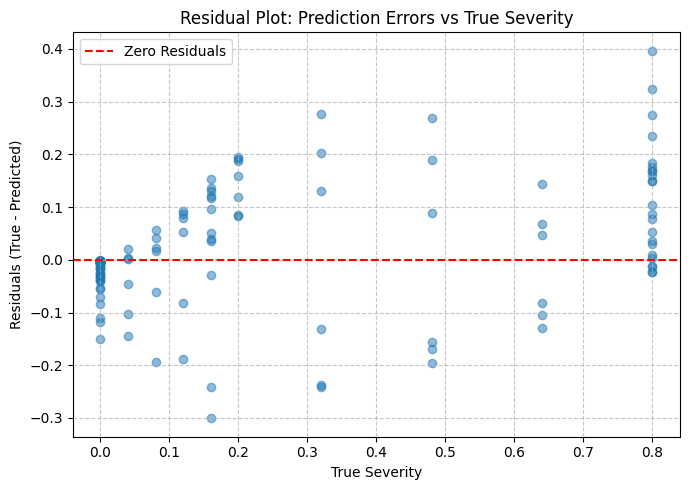

In [ ]:
# Residual Plot
residuals = all_targets - all_preds

plt.figure(figsize=(7, 5))
plt.scatter(all_targets, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.xlabel('True Severity')
plt.ylabel('Residuals (True - Predicted)')
plt.title('Residual Plot: Prediction Errors vs True Severity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

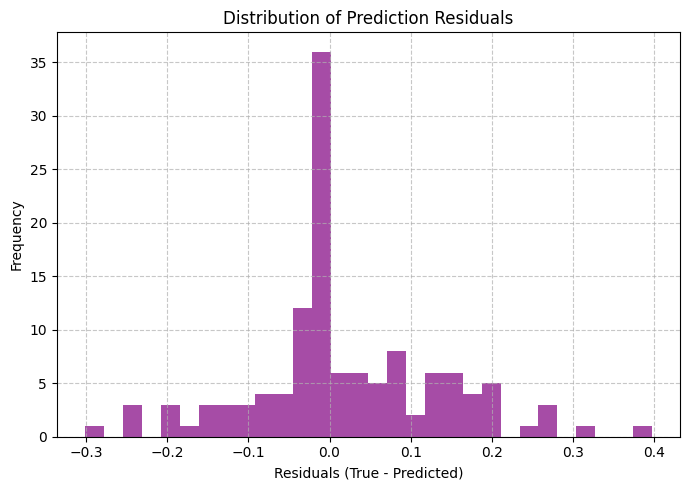

In [ ]:
# Distribution of Residuals
plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=30, alpha=0.7, color='purple')
plt.xlabel('Residuals (True - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
all_preds

array([0.02748252, 0.01473413, 0.00627436, 0.004847  , 0.00406045,
       0.00416986, 0.00561518, 0.01181761, 0.01674199, 0.0265683 ,
       0.0833592 , 0.1429185 , 0.06418571, 0.04148193, 0.02425544,
       0.00845998, 0.00437538, 0.01194682, 0.03937205, 0.02838249,
       0.02289616, 0.01960876, 0.00912098, 0.00429996, 0.0064224 ,
       0.12133462, 0.45032522, 0.6764152 , 0.76922995, 0.79011756,
       0.7125908 , 0.6497004 , 0.6312983 , 0.5651368 , 0.47593534,
       0.40345737, 0.5262609 , 0.49647003, 0.29086754, 0.19028823,
       0.12465107, 0.03132371, 0.03443545, 0.00296572, 0.00338656,
       0.00316651, 0.0024185 , 0.00229099, 0.00240633, 0.00258235,
       0.00238981, 0.00199155, 0.00175093, 0.00181342, 0.00717983,
       0.04404004, 0.2101394 , 0.5719383 , 0.7472107 , 0.7697953 ,
       0.7968408 , 0.8135038 , 0.8225745 , 0.82230216, 0.81195897,
       0.7212914 , 0.63574094, 0.5610314 , 0.4607022 , 0.07079534,
       0.04055525, 0.03689032, 0.03873697, 0.03814803, 0.03289

In [ ]:
all_targets

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.04      , 0.08      , 0.12      , 0.16      ,
       0.2       , 0.2       , 0.2       , 0.16      , 0.12      ,
       0.08      , 0.04      , 0.        , 0.        , 0.        ,
       0.16      , 0.32      , 0.48000002, 0.64      , 0.8       ,
       0.8       , 0.8       , 0.8       , 0.8       , 0.8       ,
       0.8       , 0.8       , 0.64      , 0.48000002, 0.32      ,
       0.16      , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.16      ,
       0.32      , 0.48000002, 0.64      , 0.8       , 0.8       ,
       0.8       , 0.8       , 0.8       , 0.8       , 0.8       ,
       0.64      , 0.48000002, 0.32      , 0.16      , 0.        ,
       0.        , 0.        , 0.04      , 0.08      , 0.12   

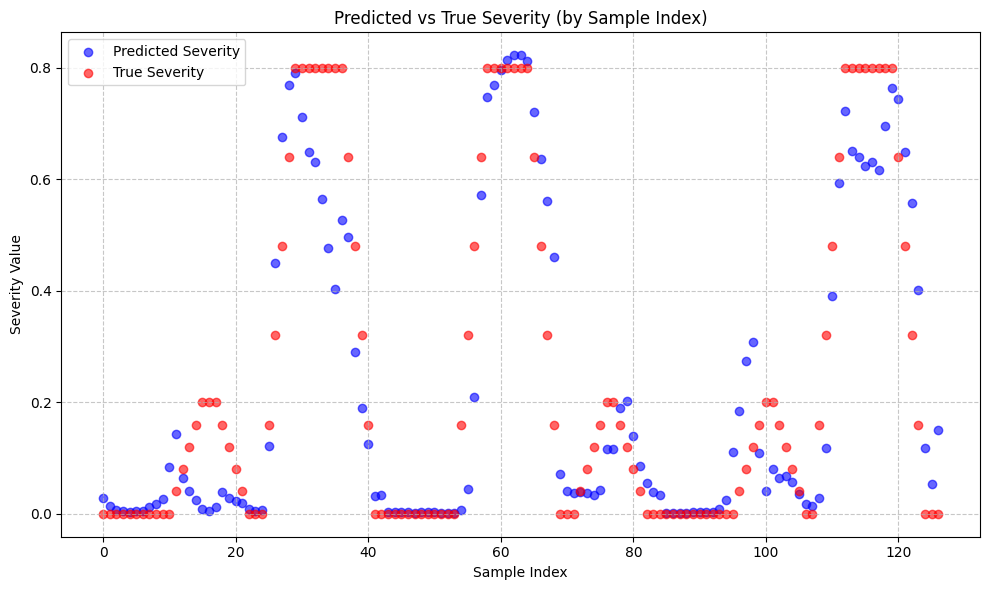

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(all_preds)), all_preds, alpha=0.6, label='Predicted Severity', color='blue')
plt.scatter(range(len(all_targets)), all_targets, alpha=0.6, label='True Severity', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Severity Value')
plt.title('Predicted vs True Severity (by Sample Index)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

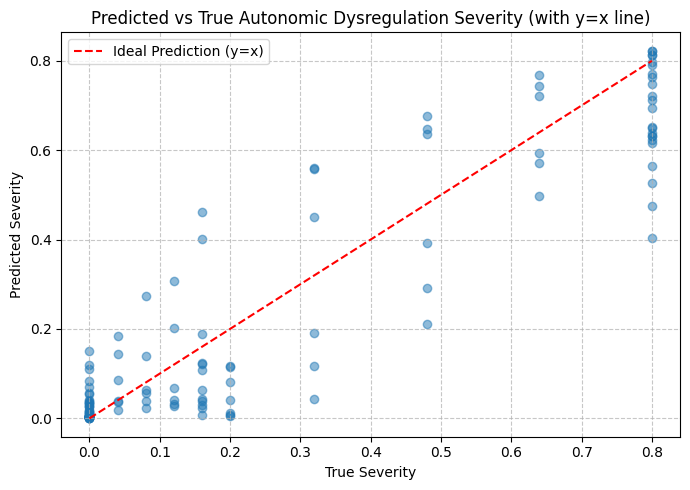

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(all_targets, all_preds, alpha=0.5)
plt.plot([min(all_targets), max(all_targets)], [min(all_targets), max(all_targets)], 'r--', label='Ideal Prediction (y=x)')
plt.xlabel('True Severity')
plt.ylabel('Predicted Severity')
plt.title('Predicted vs True Autonomic Dysregulation Severity (with y=x line)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate absolute residuals
abs_residuals = np.abs(residuals)

# Get indices of samples with largest absolute residuals
# Let's say we want to see the top 10 largest errors
num_top_errors = 10
top_error_indices = np.argsort(abs_residuals)[::-1][:num_top_errors]

print(f"Samples with the top {num_top_errors} largest prediction errors:\n")
for i, idx in enumerate(top_error_indices):
    print(f"Sample {idx}: True = {all_targets[idx]:.4f}, Predicted = {all_preds[idx]:.4f}, Error = {residuals[idx]:.4f}")

Samples with the top 10 largest prediction errors:

Sample 35: True = 0.8000, Predicted = 0.4035, Error = 0.3965
Sample 34: True = 0.8000, Predicted = 0.4759, Error = 0.3241
Sample 68: True = 0.1600, Predicted = 0.4607, Error = -0.3007
Sample 55: True = 0.3200, Predicted = 0.0440, Error = 0.2760
Sample 36: True = 0.8000, Predicted = 0.5263, Error = 0.2737
Sample 56: True = 0.4800, Predicted = 0.2101, Error = 0.2699
Sample 123: True = 0.1600, Predicted = 0.4012, Error = -0.2412
Sample 67: True = 0.3200, Predicted = 0.5610, Error = -0.2410
Sample 122: True = 0.3200, Predicted = 0.5575, Error = -0.2375
Sample 33: True = 0.8000, Predicted = 0.5651, Error = 0.2349


In [ ]:
autonomic_dysfunction_severity_WESAD = all_preds

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

full_df.to_pickle("/content/drive/MyDrive/autonomic_dysfunction_severity_WESAD.pkl")
full_df.to_parquet("autonomic_dysfunction_severity_WESAD.parquet")

# to read from saved version
# df = pd.read_pickle("/content/drive/MyDrive/wesad_full_preprocessed.pkl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
